# Analyse des Similarity-Threshold-Experiments (Metrik: MixUp Regressor)

Dieses Notebook analysiert systematisch den Einfluss des **minimalen semantischen Ähnlichkeits-Schwellenwerts** ($s_{\min} \in \{0.60, 0.70, 0.80\}$ bei $s_{\max} = 0.98$) auf die **Continuous MixUp Regressionsmetrik** (`BiLSTMRegressor`):

1. **Datenbasis & Korpuseigenschaften:** Einfluss des Schwellenwerts auf Datenvolumen, Token-Mengen und linguistische Indizes.
2. **In-Domain Test-Evaluation:** Regressionsfehler ($MSE, MAE, R^2$), Korrelationskoeffizienten ($r, \rho$) und binäre Klassifikationsgüte auf dem fixierten 10%-Held-Out-Testsplit.
3. **Out-of-Domain Generalisierung (Lebenshilfe-Benchmark):** Trennschärfe (Separation ROC-AUC) zwischen ungesehenen Dokumenten der Alltagssprache (AS) und Leichten Sprache (LS), Perfect Pair Match Rate und Score-Spreizung $\Delta = \bar{\lambda}_{LS} - \bar{\lambda}_{AS}$.
4. **KDE-Dichteverteilungs-Analyse:** Visualisierung der Vorhersage-Verteilungen (Blau für AS, Grün für LS) über alle Schwellenwert-Varianten.
5. **LaTeX-Tabellen-Export:** Formatierte Tabellen für Kapitel 3 (*Materials*) und 4 (*Methodology*) der Masterarbeit.

---

In [1]:
import os
import sys
import json
import glob
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, 'data')) and os.path.exists(os.path.join(p, 'results')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser('~/Documents/Master Thesis'))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print('Arbeitsverzeichnis:', os.getcwd())

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.dpi': 150
})

RESULTS_DIR = os.path.join(REPO_ROOT, 'results/experiments/similarity_threshold')
SUMMARY_CSV = os.path.join(RESULTS_DIR, 'similarity_threshold_summary.csv')
DETAILS_CSV = os.path.join(RESULTS_DIR, 'similarity_threshold_details.csv')


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 1. Datenretention & Korpusprofilierung über Schwellenwerte

In [2]:
CORPUS_CSV = os.path.join(REPO_ROOT, 'data/analysis/corpus_master.csv')
df_corpus = pd.read_csv(CORPUS_CSV)

threshold_stats = []
for s_min in [0.60, 0.70, 0.80, 0.85, 0.90]:
    sub = df_corpus[(df_corpus['semantic_similarity_8192'] >= s_min) & (df_corpus['semantic_similarity_8192'] <= 0.98)]
    threshold_stats.append({
        'Schwellenwert': f'[{s_min:.2f}, 0.98]',
        's_min': s_min,
        'Artikelpaare': len(sub),
        'Retention (%)': round((len(sub) / len(df_corpus)) * 100.0, 2),
        'AS Tokens': int(sub['as_tokens'].sum()) if 'as_tokens' in sub.columns else 0,
        'LS Tokens': int(sub['ls_tokens'].sum()) if 'ls_tokens' in sub.columns else 0,
        'Token-Ratio (LS/AS)': round(sub['ls_tokens'].sum() / max(1, sub['as_tokens'].sum()), 3) if 'as_tokens' in sub.columns else 0,
        'NER Recall AS->LS': round(sub['ner_recall_as_ls'].mean(), 4) if 'ner_recall_as_ls' in sub.columns else np.nan,
        'Ø Flesch LS': round(sub['ls_flesch'].mean(), 2) if 'ls_flesch' in sub.columns else np.nan,
    })

df_tstats = pd.DataFrame(threshold_stats)
display(df_tstats)


,Schwellenwert,s_min,Artikelpaare,Retention (%),AS Tokens,LS Tokens,Token-Ratio (LS/AS),NER Recall AS->LS,Ø Flesch LS
0,"[0.60, 0.98]",0.60,859,99.88,519868,377458,0.726,0.2072,61.69
1,"[0.70, 0.98]",0.70,801,93.14,496046,360170,0.726,0.2118,61.57
2,"[0.80, 0.98]",0.80,633,73.60,397951,302434,0.760,0.2272,61.69
3,"[0.85, 0.98]",0.85,421,48.95,263731,205916,0.781,0.2428,61.04
4,"[0.90, 0.98]",0.90,142,16.51,85352,76156,0.892,0.2982,58.43


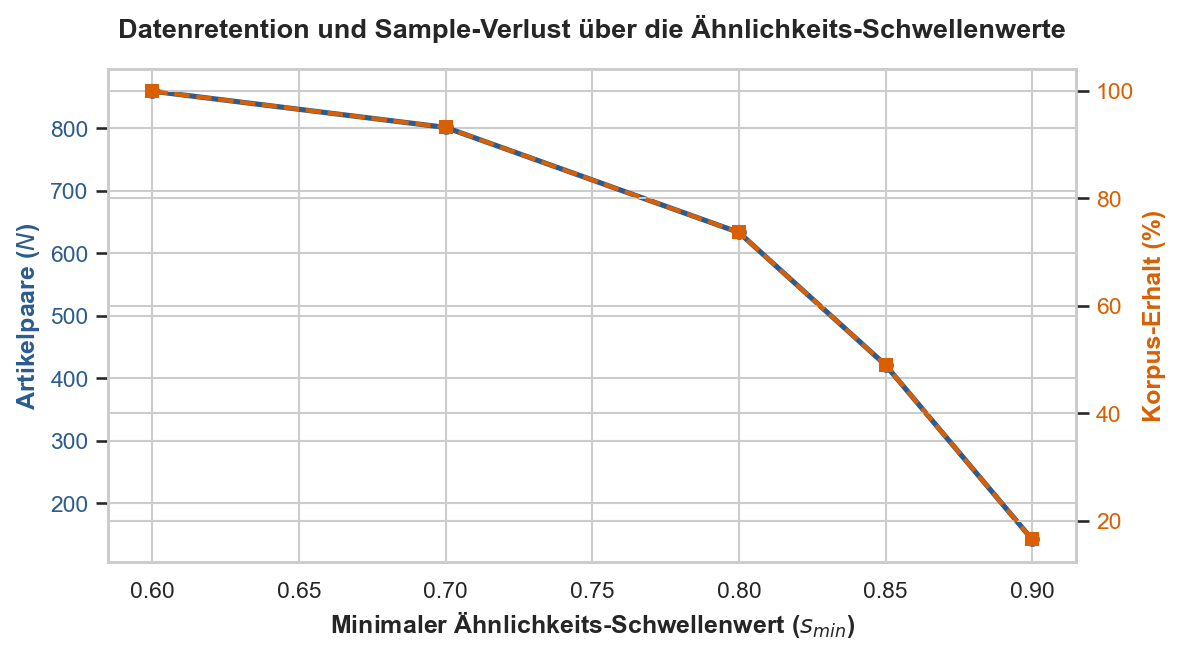

In [3]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
color = '#2b5c8f'
ax1.set_xlabel('Minimaler Ähnlichkeits-Schwellenwert ($s_{min}$)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Artikelpaare ($N$)', color=color, fontsize=12, fontweight='bold')
ax1.plot(df_tstats['s_min'], df_tstats['Artikelpaare'], marker='o', color=color, linewidth=2.5, label='Artikelpaare')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#d95f02'
ax2.set_ylabel('Korpus-Erhalt (%)', color=color, fontsize=12, fontweight='bold')
ax2.plot(df_tstats['s_min'], df_tstats['Retention (%)'], marker='s', color=color, linestyle='--', linewidth=2, label='Retention (%)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Datenretention und Sample-Verlust über die Ähnlichkeits-Schwellenwerte', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()


## 2. In-Domain Testset Evaluation (MixUp Regressor)

Vergleich von $MSE, MAE, R^2$ und Pearson-Korrelation auf dem ungesehenen Test-Split des Master-Korpus.

In [4]:
# Lade alle MixUp Metriken-Dateien
mixup_metrics_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'mixup_sim_*_metrics.json')))
mixup_records = []

for f in mixup_metrics_files:
    with open(f, 'r', encoding='utf-8') as jf:
        mixup_records.append(json.load(jf))

if mixup_records:
    df_mixup = pd.DataFrame(mixup_records).sort_values(by='min_sim')
    display(Markdown('### MixUp Regressor Metriken-Übersicht:'))
    cols = ['min_sim', 'num_train_pairs', 'in_domain_test_mse', 'in_domain_test_mae', 'in_domain_test_r2', 'in_domain_pearson_r', 'ood_separation_auc', 'ood_perfect_pair_match_pct', 'ood_score_delta']
    available_cols = [c for c in cols if c in df_mixup.columns]
    display(df_mixup[available_cols])
else:
    print('Keine MixUp Metriken gefunden. Bitte Trainingsskripte ausführen.')
    df_mixup = pd.DataFrame()


### MixUp Regressor Metriken-Übersicht:

,min_sim,num_train_pairs,in_domain_test_mse,in_domain_test_mae,in_domain_test_r2,in_domain_pearson_r,ood_separation_auc,ood_perfect_pair_match_pct,ood_score_delta
0,0.6,687,0.01708,0.08131,0.7923,0.9039,1.0000,100.0,0.7716
1,0.7,640,0.01508,0.07338,0.8199,0.9124,0.9993,100.0,0.7293
2,0.8,505,0.01928,0.09137,0.7524,0.8785,1.0000,100.0,0.7243


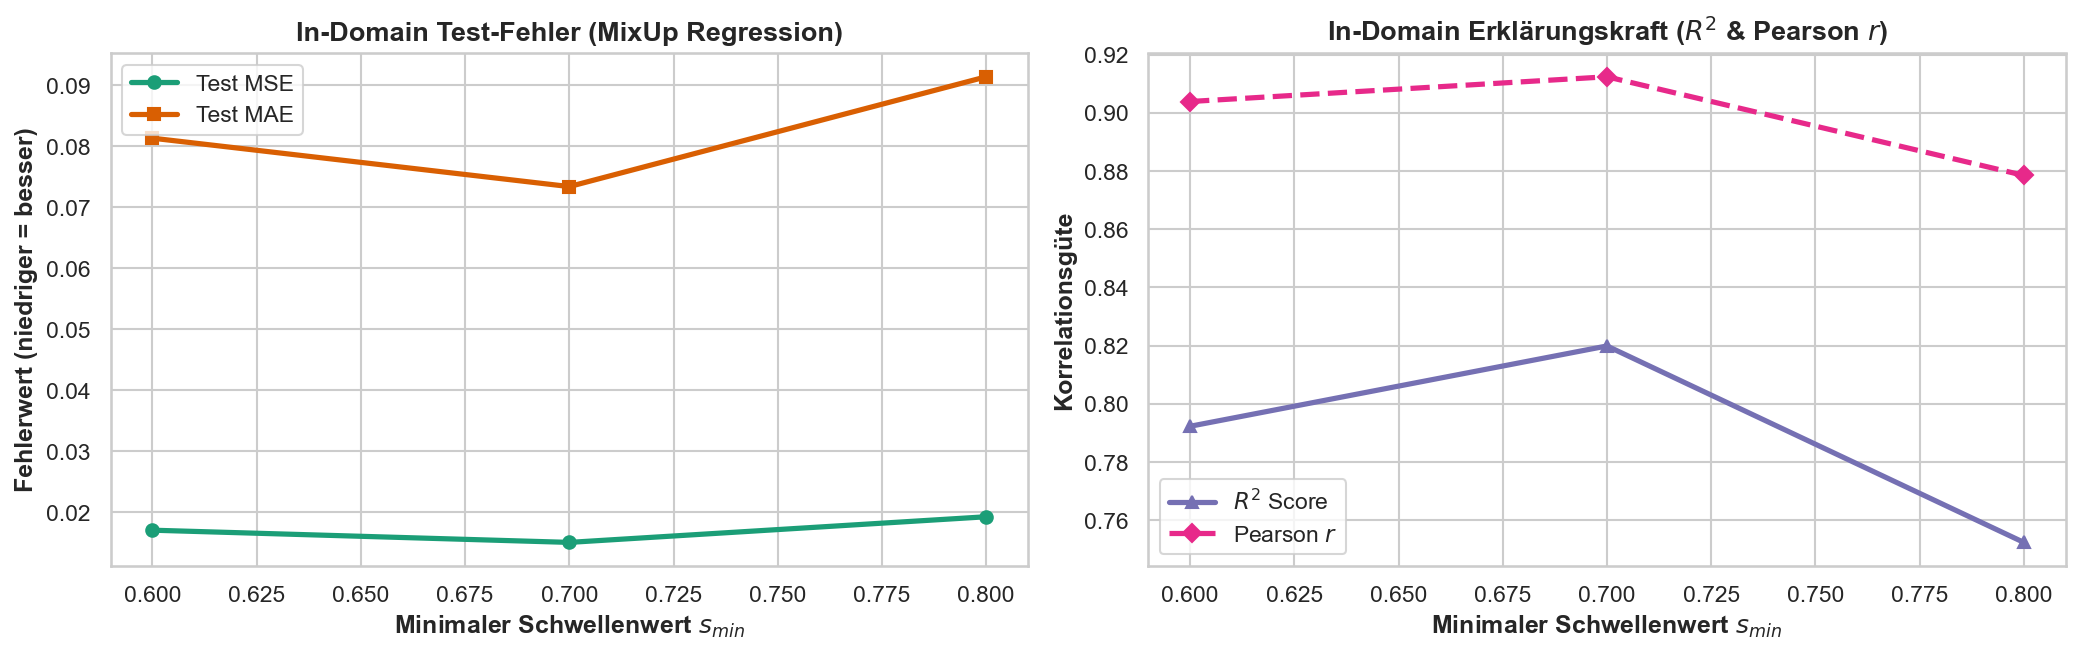

In [5]:
if not df_mixup.empty and len(df_mixup) >= 2:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
    
    # Subplot 1: In-Domain Fehlermaße
    ax1.plot(df_mixup['min_sim'], df_mixup['in_domain_test_mse'], marker='o', color='#1b9e77', linewidth=2.5, label='Test MSE')
    ax1.plot(df_mixup['min_sim'], df_mixup['in_domain_test_mae'], marker='s', color='#d95f02', linewidth=2.5, label='Test MAE')
    ax1.set_xlabel('Minimaler Schwellenwert $s_{min}$', fontweight='bold')
    ax1.set_ylabel('Fehlerwert (niedriger = besser)', fontweight='bold')
    ax1.set_title('In-Domain Test-Fehler (MixUp Regression)', fontweight='bold')
    ax1.legend()
    
    # Subplot 2: In-Domain R2 und Pearson
    ax2.plot(df_mixup['min_sim'], df_mixup['in_domain_test_r2'], marker='^', color='#7570b3', linewidth=2.5, label='$R^2$ Score')
    ax2.plot(df_mixup['min_sim'], df_mixup['in_domain_pearson_r'], marker='D', color='#e7298a', linewidth=2.5, linestyle='--', label='Pearson $r$')
    ax2.set_xlabel('Minimaler Schwellenwert $s_{min}$', fontweight='bold')
    ax2.set_ylabel('Korrelationsgüte', fontweight='bold')
    ax2.set_title('In-Domain Erklärungskraft ($R^2$ & Pearson $r$)', fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


## 3. Out-of-Domain Generalisierung auf dem Lebenshilfe-Benchmark

Untersuchung der Trennschärfe (ROC-AUC) und der Fehlerwerte auf ungesehenen Texten der *Lebenshilfe*.

In [6]:
if not df_mixup.empty and 'ood_separation_auc' in df_mixup.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
    
    # Subplot 1: OOD AUC & Perfect Pair Match
    ax1.plot(df_mixup['min_sim'], df_mixup['ood_separation_auc'], marker='o', color='#2b5c8f', linewidth=2.5, label='Separation ROC-AUC')
    ax1.plot(df_mixup['min_sim'], df_mixup['ood_perfect_pair_match_pct'] / 100.0, marker='s', color='#2ca02c', linewidth=2.5, linestyle='--', label='Perfect Pair Match Rate')
    ax1.set_xlabel('Minimaler Schwellenwert $s_{min}$', fontweight='bold')
    ax1.set_ylabel('Güte [0.0 - 1.0]', fontweight='bold')
    ax1.set_title('Out-of-Domain Trennschärfe (Lebenshilfe)', fontweight='bold')
    ax1.legend()
    
    # Subplot 2: Score-Spreizung Delta (LS - AS)
    ax2.plot(df_mixup['min_sim'], df_mixup['ood_score_delta'], marker='^', color='#d62728', linewidth=2.5, label='$\Delta = \bar{\lambda}_{LS} - \bar{\lambda}_{AS}$')
    ax2.set_xlabel('Minimaler Schwellenwert $s_{min}$', fontweight='bold')
    ax2.set_ylabel('Score-Differenz $\Delta$', fontweight='bold')
    ax2.set_title('Distanz zwischen LS- und AS-Verteilungspeak', fontweight='bold')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


<>:13: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:15: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:13: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:15: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_21874/1577390605.py:13: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax2.plot(df_mixup['min_sim'], df_mixup['ood_score_delta'], marker='^', color='#d62728', linewidth=2.5, label='$\Delta = \bar{\lambda}_{LS} - \bar{\lambd

ValueError: 
$\Delta = ar{\lambda}_{LS} - ar{\lambda}_{AS}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x1146ae820> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$\Delta = ar{\lambda}_{LS} - ar{\lambda}_{AS}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$\Delta = ar{\lambda}_{LS} - ar{\lambda}_{AS}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 2100x675 with 2 Axes>